# Experimento Final — Knowledge Distillation

**MO434 - Aprendizado Profundo para Visao Computacional**

---

## Sobre este notebook

Este notebook implementa o **experimento final do projeto**, consolidando os resultados
das ablacoes documentadas em `guia_knowledge_distillation_t3.ipynb`.

Aquele notebook de estudo cobre:
- Secoes 1–3: datasets, teachers e Fase 1
- Secoes 4–6: arquitetura do student, funcoes de perda e Fase 2
- Secoes 7–9: Q5 (RKD), Fase 3 e eficiencia
- Secao 10: checklist de proximos passos

---

## Plano de experimentos

| # | Secao | O que responde |
|---|-------|---------------|
| 1 | Datasets | — |
| 2 | Fase 1 — todos os teachers, ambos os datasets | base para Q1 e entrega final |
| 3 | **Q1** — qual teacher transfere melhor? | 3 teachers × 2 datasets |
| 4 | **Q3 por teacher** — melhor encoder para cada teacher | entrega: best student por teacher |
| 5 | Treino definitivo — best student por teacher (50 ep) | Q1 + Q3 definitivos |
| 6 | **Q5** — MSE+CE vs RKD | literatura de KD |
| 7 | GFLOPs e eficiencia computacional | Q3 (saving GFLOPs e params) |
| 8 | Relatorio final consolidado | todas as questoes |

## Sintese das ablacoes (guia_knowledge_distillation_t3)

| Pergunta | Melhor | acc_test |
|----------|--------|---------|
| Q2 — target | post_gap | 0.2495 (2.5× > pre_gap) |
| Q4 — alpha | **0.5** | 0.2542 |

Essas conclusoes sao aplicadas diretamente: usamos `post_gap` e `alpha=0.5` em todos os
experimentos deste notebook.


---
## Secao 0 — Importacoes e Configuracao


In [8]:
# instala fvcore para calculo de GFLOPs (tenta silenciosamente)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fvcore', '-q'], capture_output=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

from kd_run import (
    set_seed, Timer,
    ImageTransforms, DatasetManager,
    TeacherWrapper,
    PlainCNNEncoder, DepthwiseCNNEncoder, MiniResNetEncoder,
    PreditorPostGAP, PreditorPreGAP, StudentModel,
    PerdaKD, PerdaRKD,
    Trainer, Evaluator,
    plotar_curvas, plotar_comparacao_mse_rkd,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'dispositivo: {device}')
if torch.cuda.is_available():
    print(f'gpu: {torch.cuda.get_device_name(0)}')
    print(f'memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


dispositivo: cuda
gpu: NVIDIA GeForce RTX 3090
memoria: 25.8 GB


In [9]:
# ── configuracoes globais ─────────────────────────────────────────────────────
SEED             = 42
BATCH_SIZE       = 32
NUM_WORKERS      = 2
STUDENT_CHANNELS = (32, 64, 128, 256)

# melhores hiperparametros das ablacoes (guia_knowledge_distillation_t3)
MELHOR_TARGET = 'post_gap'   # Q2: post_gap >> pre_gap
MELHOR_ALPHA  = 0.5          # Q4: melhor alpha entre 0, 0.5, 0.7, 1.0
EPOCHS_FASE1  = 15
EPOCHS_Q3     = 30           # ablacao de encoder (nao precisa ser definitiva)
EPOCHS_FINAL  = 50           # treino definitivo por teacher
LR            = 1e-3

TEACHERS  = ['resnet50', 'vgg16', 'convnext_small']
DATASETS_NOMES = ['flowers102', 'pets']
ENCODERS  = [
    ('PlainCNN',    PlainCNNEncoder),
    ('Depthwise',   DepthwiseCNNEncoder),
    ('MiniResNet',  MiniResNetEncoder),
]

# mapa nome -> classe (usado por multiplas secoes, inclusive nas funcoes de restore)
ENCODER_CLASSES = {
    'PlainCNN':   PlainCNNEncoder,
    'Depthwise':  DepthwiseCNNEncoder,
    'MiniResNet': MiniResNetEncoder,
}

trainer   = Trainer(device=device, seed=SEED)
evaluator = Evaluator(device=device)
CKPT_DIR  = 'checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── helper: GFLOPs via fvcore (fallback: None) ────────────────────────────────
def gflops_params(model, input_size=(1, 3, 224, 224)):
    model.eval()
    dummy = torch.randn(*input_size)
    params = sum(p.numel() for p in model.parameters()) / 1e6
    try:
        from fvcore.nn import FlopCountAnalysis
        gf = FlopCountAnalysis(model.cpu(), dummy).total() / 1e9
        return round(gf, 3), round(params, 3)
    except Exception:
        return None, round(params, 3)

print('configuracoes prontas.')


semente fixada: 42 (random, numpy, torch, cuda)
configuracoes prontas.


In [10]:
# ── helpers de checkpoint: salvar/restaurar estado entre secoes ───────────────
# Permitem retomar o notebook a partir de qualquer secao sem re-treinar tudo.
# Pre-requisito: Secoes 0 e 1 (imports + datasets) devem ser rodadas primeiro.
import json, pickle

def salvar_fase1(resultados):
    """Salva resumo da Fase 1 em disco (classifier .pth ja salvo durante o treino)."""
    summary = {t: {} for t in TEACHERS}
    for t in TEACHERS:
        for ds in DATASETS_NOMES:
            summary[t][ds] = {'acc_test': resultados[t][ds]['acc_test']}
    with open(f'{CKPT_DIR}/fase1_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    print('[checkpoint] fase1_summary.json salvo.')

def restaurar_fase1():
    """Reconstroi resultados_fase1 carregando classifier .pth do disco."""
    with open(f'{CKPT_DIR}/fase1_summary.json') as f:
        summary = json.load(f)
    res = {t: {} for t in TEACHERS}
    for t in TEACHERS:
        for ds in DATASETS_NOMES:
            n_classes = DATASETS[ds]['n_classes']
            teacher = TeacherWrapper(t, n_classes=n_classes)
            ckpt_path = f'{CKPT_DIR}/classifier_{t}_{ds}.pth'
            teacher.classifier.load_state_dict(
                torch.load(ckpt_path, map_location='cpu'))
            teacher.eval()
            res[t][ds] = {
                'teacher_obj': teacher,
                'acc_test': summary[t][ds]['acc_test'],
            }
    print('[checkpoint] resultados_fase1 restaurado do disco.')
    return res

def _garantir_fase1():
    """Retorna resultados_fase1 da memoria ou o restaura do disco."""
    import builtins
    if 'resultados_fase1' not in dir(builtins) and 'resultados_fase1' not in globals():
        print('resultados_fase1 nao encontrado em memoria — restaurando...')
        return restaurar_fase1()
    return globals().get('resultados_fase1')

def salvar_final(resultados):
    """Salva historicos e resumo dos treinos definitivos (student .pth ja salvo)."""
    summary = {}
    for t in TEACHERS:
        summary[t] = {}
        for ds in DATASETS_NOMES:
            r = resultados[t][ds]
            summary[t][ds] = {
                'acc_test':      r['acc_test'],
                'acc_top5':      r['acc_top5'],
                'params_M':      r['params_M'],
                'encoder':       r['encoder'],
                'melhor_acc_val': r['melhor_acc_val'],
            }
            with open(f'{CKPT_DIR}/hist_{t}_{ds}.pkl', 'wb') as f:
                pickle.dump(r['historico'], f)
    with open(f'{CKPT_DIR}/final_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    print('[checkpoint] final_summary.json e historicos salvos.')

def restaurar_final():
    """Reconstroi resultados_final carregando student state_dicts do disco."""
    with open(f'{CKPT_DIR}/final_summary.json') as f:
        summary = json.load(f)
    with open(f'{CKPT_DIR}/best_encoder.json') as f:
        enc_map = json.load(f)
    res = {}
    for t in TEACHERS:
        res[t] = {}
        for ds in DATASETS_NOMES:
            r = summary[t][ds]
            EncoderCls = ENCODER_CLASSES[r['encoder']]
            n_classes = DATASETS[ds]['n_classes']
            teacher_tmp = TeacherWrapper(t, n_classes=n_classes)
            enc  = EncoderCls(STUDENT_CHANNELS)
            pred = PreditorPostGAP(enc.out_dim, teacher_tmp.feat_dim)
            student = StudentModel(enc, pred)
            ckpt = f'{CKPT_DIR}/best_student_{t}_{ds}.pth'
            student.load_state_dict(torch.load(ckpt, map_location='cpu'))
            student.eval()
            with open(f'{CKPT_DIR}/hist_{t}_{ds}.pkl', 'rb') as f:
                hist = pickle.load(f)
            res[t][ds] = {'student_obj': student, 'historico': hist, **r}
    print('[checkpoint] resultados_final restaurado do disco.')
    return res

print('Helpers de checkpoint prontos.')


Helpers de checkpoint prontos.


---
## Secao 1 — Datasets

- **Flowers-102**: 102 classes de flores, ~8K imagens, splits oficiais
- **Oxford-IIIT-Pet**: 37 racas de caes e gatos, ~7K imagens


In [11]:
with Timer('carregamento dos datasets'):
    dm = DatasetManager(data_root='./data', batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    DATASETS = dm.load_all()

for nome in DATASETS_NOMES:
    print(f'{nome:12s}: {DATASETS[nome]["n_classes"]} classes')


flowers-102 -> treino: 1,020 | val: 1,020 | teste: 6,149
oxford-pets -> treino: 2,944 | val: 736 | teste: 3,669
[timer] carregamento dos datasets                     -> 0.30 s
flowers102  : 102 classes
pets        : 37 classes


---
## Secao 2 — Fase 1: Treino do Classificador (todos os teachers)

Para cada teacher e cada dataset, congela o encoder e treina apenas o classificador.
O classificador salvo aqui sera reutilizado **exatamente** na Fase 3.

Total: 3 teachers × 2 datasets = **6 runs**.


In [5]:
# ── Fase 1: 3 teachers × 2 datasets ─────────────────────────────────────────
# resultados_fase1[teacher][dataset] = {'teacher_obj', 'acc_test'}
resultados_fase1 = {t: {} for t in TEACHERS}

for nome_teacher in TEACHERS:
    for dataset_nome in DATASETS_NOMES:
        n_classes = DATASETS[dataset_nome]['n_classes']
        print(f'\n{"-"*55}')
        print(f' {nome_teacher} | {dataset_nome} ({n_classes} classes)')
        print(f'{"-"*55}')

        teacher = TeacherWrapper(nome_teacher, n_classes=n_classes).to(device)
        teacher.freeze_encoder()

        params_tr = [p for p in teacher.parameters() if p.requires_grad]
        optimizer = optim.Adam(params_tr, lr=LR, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FASE1)

        with Timer(f'fase1 {nome_teacher}/{dataset_nome}'):
            hist = trainer.treinar_fase1(
                model        = teacher,
                loader_train = DATASETS[dataset_nome]['train'],
                loader_val   = DATASETS[dataset_nome]['val'],
                optimizer    = optimizer,
                scheduler    = scheduler,
                n_epochs     = EPOCHS_FASE1,
                descricao    = f'{nome_teacher}_{dataset_nome}',
            )

        acc_test = trainer.avaliar_loader(teacher, DATASETS[dataset_nome]['test'])
        print(f'  acc_test: {acc_test:.4f}')

        torch.save(teacher.classifier.state_dict(),
                   f'checkpoints/classifier_{nome_teacher}_{dataset_nome}.pth')

        resultados_fase1[nome_teacher][dataset_nome] = {
            'teacher_obj': teacher,
            'acc_test':    acc_test,
        }

        # libera GPU apos salvar (sera restaurado quando necessario)
        teacher.cpu()

print('\nFase 1 concluida.')



-------------------------------------------------------
 resnet50 | flowers102 (102 classes)
-------------------------------------------------------


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/beth/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 25.9MB/s]


encoder resnet50 congelado.


  epoca   1 | loss_tr=4.3613 acc_tr=0.162 | loss_vl=3.7992 acc_vl=0.591 | gap=-0.429


  epoca   5 | loss_tr=1.5244 acc_tr=0.969 | loss_vl=1.9042 acc_vl=0.837 | gap=+0.132


...

  epoca  15 | loss_tr=0.3637 acc_tr=0.976 | loss_vl=0.6122 acc_vl=0.901 | gap=+0.075
  melhor acc validacao: 0.9047 (epoca 11)
[timer] fase1 convnext_small/flowers102               -> 1 min 33.4 s
  acc_test: 0.8685

-------------------------------------------------------
 convnext_small | pets (37 classes)
-------------------------------------------------------
encoder convnext_small congelado.


  epoca   1 | loss_tr=1.1866 acc_tr=0.765 | loss_vl=0.2863 acc_vl=0.932 | gap=-0.167


  epoca   5 | loss_tr=0.1304 acc_tr=0.968 | loss_vl=0.1704 acc_vl=0.951 | gap=+0.017


  epoca  10 | loss_tr=0.0787 acc_tr=0.980 | loss_vl=0.1206 acc_vl=0.957 | gap=+0.023


  epoca  15 | loss_tr=0.0688 acc_tr=0.986 | loss_vl=0.1208 acc_vl=0.955 | gap=+0.031
  melhor acc validacao: 0.9728 (epoca 12)
[timer] fase1 convnext_small/pets                     -> 2 min 36.6 s
  acc_test: 0.9334

Fase 1 concluida.


In [6]:
# ── [CHECKPOINT] Salvar resultados da Fase 1 ─────────────────────────────────
# Os arquivos classifier_*.pth ja foram salvos durante o treino acima.
# Aqui salvamos apenas o resumo de acc_test para poder restaurar nas secoes seguintes.
salvar_fase1(resultados_fase1)
print('Secao 2 concluida e persistida. Proximas secoes podem ser retomadas do disco.')


[checkpoint] fase1_summary.json salvo.
Secao 2 concluida e persistida. Proximas secoes podem ser retomadas do disco.


---
## Secao 3 — Q1: Qual teacher transfere melhor?

Comparamos os 3 teachers usando o melhor student das ablacoes
(PlainCNN, post_gap, alpha=0.5) em **ambos os datasets**.


In [7]:
# ── [RESTORE] Secao 3 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()


[ok] resultados_fase1 ja em memoria.


  ep.  1 | mse=0.0369 | acc_tr=0.010 acc_vl=0.013 | gap=-0.003


  ep.  5 | mse=0.0333 | acc_tr=0.072 acc_vl=0.093 | gap=-0.021


  ep. 10 | mse=0.0327 | acc_tr=0.155 acc_vl=0.169 | gap=-0.014


  ep. 15 | mse=0.0318 | acc_tr=0.235 acc_vl=0.210 | gap=+0.025


  ep. 20 | mse=0.0313 | acc_tr=0.302 acc_vl=0.260 | gap=+0.042


...

  ep. 15 | mse=0.0111 | acc_tr=0.178 acc_vl=0.155 | gap=+0.023


  ep. 20 | mse=0.0106 | acc_tr=0.246 acc_vl=0.181 | gap=+0.066


  ep. 23 | mse=0.0104 | acc_tr=0.265 acc_vl=0.213 | gap=+0.052  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 25 | mse=0.0103 | acc_tr=0.274 acc_vl=0.235 | gap=+0.039


  ep. 30 | mse=0.0101 | acc_tr=0.286 acc_vl=0.266 | gap=+0.020
  melhor acc validacao: 0.2663 (epoca 30)
[timer] Q1 convnext_small/pets                        -> 5 min 12.5 s

 Q1 — Qual teacher transfere melhor?

  Top-1 accuracy:
dataset         flowers102      pets
teacher                             
convnext_small    0.139475  0.220380
resnet50          0.252267  0.232065
vgg16             0.206898  0.273926

  Top-5 accuracy:
dataset         flowers102      pets
teacher                             
convnext_small    0.404080  0.565541
resnet50          0.536205  0.598680
vgg16             0.492163  0.656742


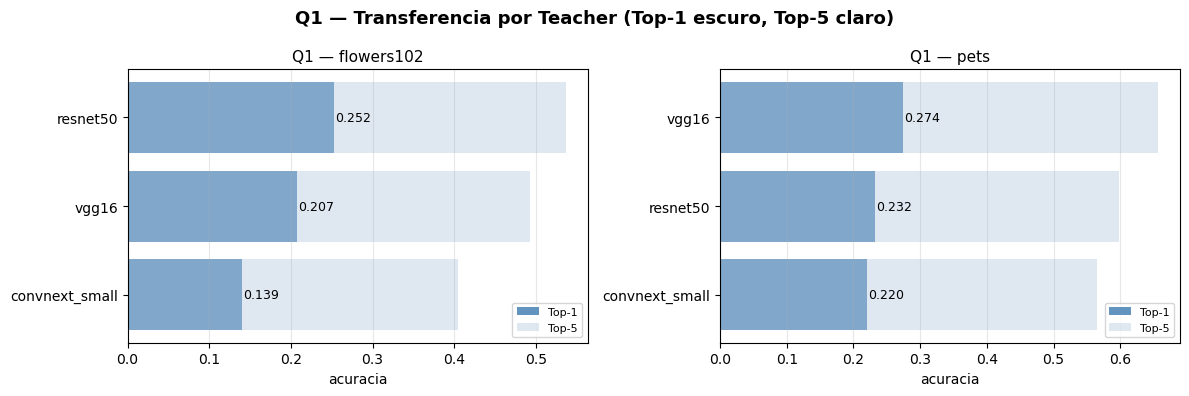

In [8]:
# ── Q1: 3 teachers × 2 datasets (PlainCNN, post_gap, alpha=0.5, 30 ep) ────────
resultados_q1 = []

for nome_teacher in TEACHERS:
    for dataset_nome in DATASETS_NOMES:
        teacher = resultados_fase1[nome_teacher][dataset_nome]['teacher_obj'].to(device)

        enc     = PlainCNNEncoder(STUDENT_CHANNELS)
        pred    = PreditorPostGAP(enc.out_dim, teacher.feat_dim)
        student = StudentModel(enc, pred).to(device)

        perda_fn = PerdaKD(alpha=MELHOR_ALPHA)
        with Timer(f'Q1 {nome_teacher}/{dataset_nome}'):
            hist, _ = trainer.treinar_fase2(
                student      = student,
                teacher      = teacher,
                loader_train = DATASETS[dataset_nome]['train'],
                loader_val   = DATASETS[dataset_nome]['val'],
                perda_fn     = perda_fn,
                n_epochs     = EPOCHS_Q3,
                lr           = LR,
                modo_target  = MELHOR_TARGET,
                descricao    = f'q1_{nome_teacher}_{dataset_nome}',
            )

        acc_test, acc_top5 = evaluator.avaliar_fase3(
            student, teacher, DATASETS[dataset_nome]['test'], MELHOR_TARGET)

        resultados_q1.append({
            'teacher':  nome_teacher,
            'dataset':  dataset_nome,
            'acc_test': acc_test,
            'acc_top5': acc_top5,   # relevante especialmente para flowers102 (102 classes)
        })
        teacher.cpu(); student.cpu()

df_q1 = pd.DataFrame(resultados_q1)

print('\n' + '='*60)
print(' Q1 — Qual teacher transfere melhor?')
print('='*60)
print('\n  Top-1 accuracy:')
piv1 = df_q1.pivot(index='teacher', columns='dataset', values='acc_test')
print(piv1.to_string())

# top-5 (flowers102 tem 102 classes: top-5 e mais informativo)
df_top5 = df_q1[df_q1['acc_top5'].notna()]
if not df_top5.empty:
    print('\n  Top-5 accuracy:')
    piv5 = df_top5.pivot(index='teacher', columns='dataset', values='acc_top5')
    print(piv5.to_string())

# grafico Q1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ds in zip(axes, DATASETS_NOMES):
    dados = df_q1[df_q1['dataset'] == ds].sort_values('acc_test', ascending=True)
    ax.barh(dados['teacher'], dados['acc_test'], color='steelblue', alpha=0.85,
            label='Top-1')
    # top-5 como marcador adicional
    top5_vals = dados['acc_top5'].values
    if any(v is not None for v in top5_vals):
        top5_clean = [v if v else 0 for v in top5_vals]
        ax.barh(dados['teacher'], top5_clean, color='lightsteelblue', alpha=0.4,
                label='Top-5')
    ax.set_title(f'Q1 — {ds}', fontsize=11)
    ax.set_xlabel('acuracia'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')
    for i, (_, row) in enumerate(dados.iterrows()):
        ax.text(row['acc_test'] + 0.002, i, f"{row['acc_test']:.3f}", va='center', fontsize=9)
plt.suptitle('Q1 — Transferencia por Teacher (Top-1 escuro, Top-5 claro)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [9]:
# ── [CHECKPOINT] Salvar resultados Q1 ────────────────────────────────────────
df_q1.to_csv(f'{CKPT_DIR}/results_q1.csv', index=False)
print('[checkpoint] results_q1.csv salvo.')


[checkpoint] results_q1.csv salvo.


---
## Secao 4 — Q3 por Teacher: Melhor Encoder para cada Teacher

Para cada teacher identificamos qual dos 3 encoders produz a maior acuracia no
Flowers-102 (flores: dominio mais discriminativo, ideal para comparar arquiteturas).

**Entrega exigida pelo enunciado**: "provide the notebooks/Python scripts with the
best student architecture for each teacher."

Total: 3 teachers × 3 encoders = **9 runs** (30 epocas cada).


In [10]:
# ── [RESTORE] Secao 4 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()


[ok] resultados_fase1 ja em memoria.


  ep.  1 | mse=0.0368 | acc_tr=0.008 acc_vl=0.010 | gap=-0.002


  ep.  5 | mse=0.0336 | acc_tr=0.074 acc_vl=0.090 | gap=-0.016


  ep. 10 | mse=0.0325 | acc_tr=0.165 acc_vl=0.137 | gap=+0.029


  ep. 15 | mse=0.0321 | acc_tr=0.215 acc_vl=0.214 | gap=+0.002


  ep. 20 | mse=0.0313 | acc_tr=0.288 acc_vl=0.256 | gap=+0.032


...

  ep.  1 | mse=0.0122 | acc_tr=0.011 acc_vl=0.022 | gap=-0.012


  ep.  5 | mse=0.0077 | acc_tr=0.039 acc_vl=0.043 | gap=-0.004


  ep. 10 | mse=0.0072 | acc_tr=0.070 acc_vl=0.102 | gap=-0.032


  ep. 15 | mse=0.0072 | acc_tr=0.100 acc_vl=0.109 | gap=-0.009


  ep. 16 | mse=0.0070 | acc_tr=0.099 acc_vl=0.105 | gap=-0.006  [OVERFITTING: val_loss subindo 3x seguidas]
  early stopping na epoca 16 (sem melhora por 5 epocas). melhor: epoca 11
  melhor acc validacao: 0.1133 (epoca 11)
[timer] Q3 convnext_small/MiniResNet                  -> 1 min 42.6 s

 Q3 — Melhor encoder por teacher (flowers102)

  resnet50
   encoder  acc_test  params_M
 Depthwise  0.244495  1.229504
  PlainCNN  0.242228  1.571104
MiniResNet  0.171632  3.121184

  vgg16
   encoder  acc_test  params_M
  PlainCNN  0.193944  0.783136
 Depthwise  0.179145  0.441536
MiniResNet  0.159877  2.333216

  convnext_small
   encoder  acc_test  params_M
  PlainCNN  0.160363  0.914464
 Depthwise  0.150583  0.572864
MiniResNet  0.074968  2.464544

Melhor encoder por teacher:
  convnext_small       -> PlainCNN
  resnet50             -> Depthwise
  vgg16                -> PlainCNN


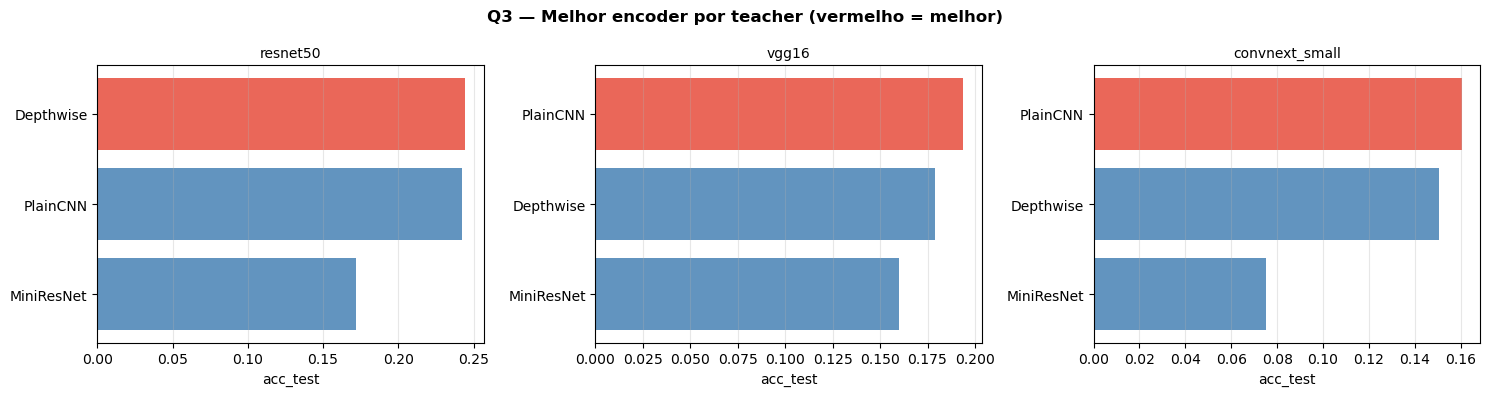

In [11]:
# ── Q3: melhor encoder por teacher (flowers102, post_gap, alpha=0.5, 30 ep) ───
resultados_q3 = []

for nome_teacher in TEACHERS:
    teacher = resultados_fase1[nome_teacher]['flowers102']['teacher_obj'].to(device)

    for enc_nome, EncoderCls in ENCODERS:
        enc     = EncoderCls(STUDENT_CHANNELS)
        pred    = PreditorPostGAP(enc.out_dim, teacher.feat_dim)
        student = StudentModel(enc, pred).to(device)
        params_s = sum(p.numel() for p in student.parameters()) / 1e6

        perda_fn = PerdaKD(alpha=MELHOR_ALPHA)
        with Timer(f'Q3 {nome_teacher}/{enc_nome}'):
            hist, melhor_acc_val = trainer.treinar_fase2(
                student      = student,
                teacher      = teacher,
                loader_train = DATASETS['flowers102']['train'],
                loader_val   = DATASETS['flowers102']['val'],
                perda_fn     = perda_fn,
                n_epochs     = EPOCHS_Q3,
                lr           = LR,
                modo_target  = MELHOR_TARGET,
                descricao    = f'q3_{nome_teacher}_{enc_nome}',
            )

        acc_test, _ = evaluator.avaliar_fase3(
            student, teacher, DATASETS['flowers102']['test'], MELHOR_TARGET)

        resultados_q3.append({
            'teacher':   nome_teacher,
            'encoder':   enc_nome,
            'acc_test':  acc_test,
            'params_M':  params_s,
        })
        student.cpu()

    teacher.cpu()

df_q3 = pd.DataFrame(resultados_q3)
print('\n' + '='*60)
print(' Q3 — Melhor encoder por teacher (flowers102)')
print('='*60)
for t in TEACHERS:
    sub = df_q3[df_q3['teacher'] == t].sort_values('acc_test', ascending=False)
    print(f'\n  {t}')
    print(sub[['encoder','acc_test','params_M']].to_string(index=False))

# identifica best encoder por teacher
best_encoder_por_teacher = (
    df_q3.sort_values('acc_test', ascending=False)
         .groupby('teacher')
         .first()['encoder']
         .to_dict()
)
print('\nMelhor encoder por teacher:')
for t, enc in best_encoder_por_teacher.items():
    print(f'  {t:20s} -> {enc}')

# grafico Q3
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TEACHERS):
    sub = df_q3[df_q3['teacher'] == t].sort_values('acc_test', ascending=True)
    cores = ['#e74c3c' if enc == best_encoder_por_teacher[t] else 'steelblue'
             for enc in sub['encoder']]
    ax.barh(sub['encoder'], sub['acc_test'], color=cores, alpha=0.85)
    ax.set_title(f'{t}', fontsize=10)
    ax.set_xlabel('acc_test'); ax.grid(True, alpha=0.3, axis='x')
plt.suptitle('Q3 — Melhor encoder por teacher (vermelho = melhor)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


In [12]:
# ── [CHECKPOINT] Salvar resultados Q3 e melhor encoder por teacher ───────────
df_q3.to_csv(f'{CKPT_DIR}/results_q3.csv', index=False)
with open(f'{CKPT_DIR}/best_encoder.json', 'w') as f:
    json.dump(best_encoder_por_teacher, f, indent=2)
print('[checkpoint] results_q3.csv e best_encoder.json salvos.')


[checkpoint] results_q3.csv e best_encoder.json salvos.


---
## Secao 5 — Treino Definitivo: Best Student por Teacher (50 epocas)

Usa o melhor encoder identificado na Secao 4 para cada teacher,
treinando com 50 epocas em **ambos os datasets**.

Os checkpoints salvos aqui sao a **entrega final** do projeto.


In [13]:
# ── [RESTORE] Secao 5 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()

try:
    _ = best_encoder_por_teacher
    print('[ok] best_encoder_por_teacher ja em memoria.')
except NameError:
    with open(f'{CKPT_DIR}/best_encoder.json') as f:
        best_encoder_por_teacher = json.load(f)
    print('[checkpoint] best_encoder_por_teacher carregado do disco.')

try:
    _ = df_q3
    print('[ok] df_q3 ja em memoria.')
except NameError:
    df_q3 = pd.read_csv(f'{CKPT_DIR}/results_q3.csv')
    print('[checkpoint] df_q3 carregado do disco.')


[ok] resultados_fase1 ja em memoria.
[ok] best_encoder_por_teacher ja em memoria.
[ok] df_q3 ja em memoria.



------------------------------------------------------------
 resnet50 | Depthwise | flowers102
 params: 1.23M
------------------------------------------------------------


  ep.  1 | mse=0.0368 | acc_tr=0.010 acc_vl=0.010 | gap=+0.000


  ep.  5 | mse=0.0334 | acc_tr=0.082 acc_vl=0.075 | gap=+0.007


  ep. 10 | mse=0.0328 | acc_tr=0.166 acc_vl=0.155 | gap=+0.012


  ep. 15 | mse=0.0321 | acc_tr=0.243 acc_vl=0.234 | gap=+0.009


...

  ep. 35 | mse=0.0299 | acc_tr=0.414 acc_vl=0.363 | gap=+0.051


  ep. 38 | mse=0.0303 | acc_tr=0.414 acc_vl=0.368 | gap=+0.046  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 40 | mse=0.0299 | acc_tr=0.426 acc_vl=0.362 | gap=+0.064


  ep. 45 | mse=0.0298 | acc_tr=0.423 acc_vl=0.369 | gap=+0.054


  early stopping na epoca 49 (sem melhora por 5 epocas). melhor: epoca 44
  melhor acc validacao: 0.3749 (epoca 44)
[timer] final resnet50/flowers102                     -> 5 min 8.3 s
  melhor acc val : 0.3749
  acc_test (F3)  : 0.3067
  acc_top5       : 0.5911
  checkpoint     : checkpoints/best_student_resnet50_flowers102.pth


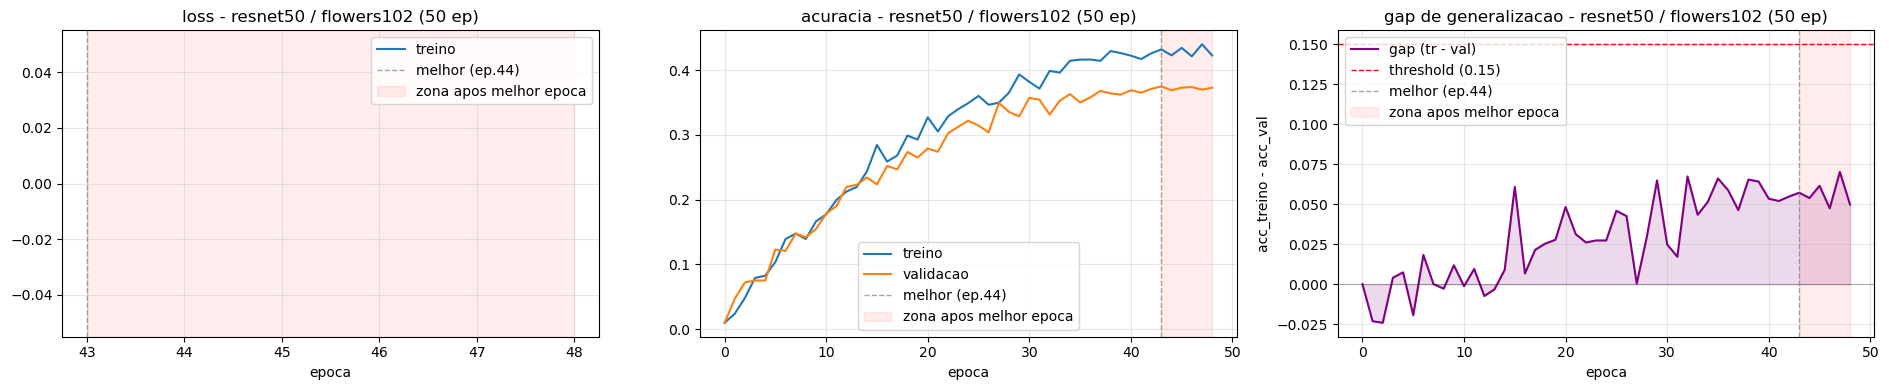


------------------------------------------------------------
 resnet50 | Depthwise | pets
 params: 1.23M
------------------------------------------------------------


  ep.  1 | mse=0.0615 | acc_tr=0.044 acc_vl=0.062 | gap=-0.018


  ep.  5 | mse=0.0579 | acc_tr=0.134 acc_vl=0.133 | gap=+0.001


  ep. 10 | mse=0.0559 | acc_tr=0.198 acc_vl=0.175 | gap=+0.023


  ep. 15 | mse=0.0548 | acc_tr=0.245 acc_vl=0.232 | gap=+0.012


  ep. 20 | mse=0.0534 | acc_tr=0.274 acc_vl=0.260 | gap=+0.014


  ep. 25 | mse=0.0522 | acc_tr=0.337 acc_vl=0.317 | gap=+0.021


  ep. 27 | mse=0.0522 | acc_tr=0.341 acc_vl=0.292 | gap=+0.049  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 30 | mse=0.0515 | acc_tr=0.356 acc_vl=0.291 | gap=+0.065
  early stopping na epoca 30 (sem melhora por 5 epocas). melhor: epoca 25
  melhor acc validacao: 0.3166 (epoca 25)
[timer] final resnet50/pets                           -> 5 min 23.8 s
  melhor acc val : 0.3166
  acc_test (F3)  : 0.2399
  acc_top5       : 0.5950
  checkpoint     : checkpoints/best_student_resnet50_pets.pth


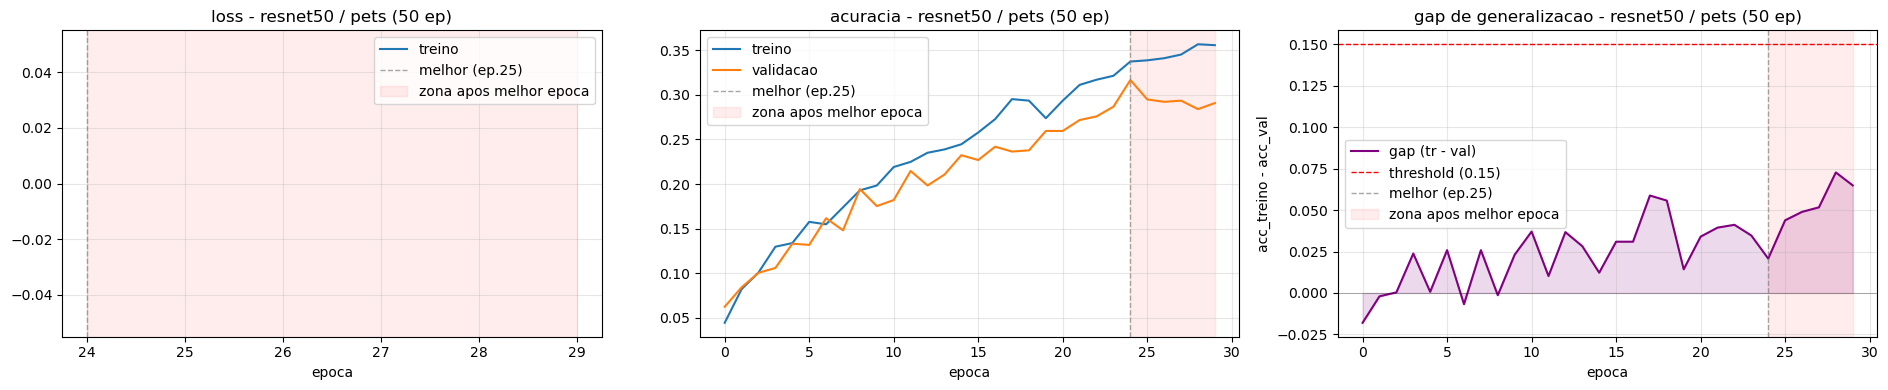


------------------------------------------------------------
 vgg16 | PlainCNN | flowers102
 params: 0.78M
------------------------------------------------------------


  ep.  1 | mse=0.1526 | acc_tr=0.032 acc_vl=0.035 | gap=-0.003


  ep.  5 | mse=0.1147 | acc_tr=0.117 acc_vl=0.127 | gap=-0.010


  ep. 10 | mse=0.1092 | acc_tr=0.157 acc_vl=0.149 | gap=+0.008


  ep. 15 | mse=0.1035 | acc_tr=0.203 acc_vl=0.187 | gap=+0.016


...

  ep. 34 | mse=0.0886 | acc_tr=0.353 acc_vl=0.289 | gap=+0.063  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 35 | mse=0.0895 | acc_tr=0.352 acc_vl=0.313 | gap=+0.039


  ep. 40 | mse=0.0857 | acc_tr=0.388 acc_vl=0.337 | gap=+0.051


  ep. 45 | mse=0.0845 | acc_tr=0.430 acc_vl=0.338 | gap=+0.092


  ep. 50 | mse=0.0842 | acc_tr=0.419 acc_vl=0.335 | gap=+0.085
  melhor acc validacao: 0.3383 (epoca 48)
[timer] final vgg16/flowers102                        -> 5 min 9.4 s
  melhor acc val : 0.3383
  acc_test (F3)  : 0.2766
  acc_top5       : 0.5564
  checkpoint     : checkpoints/best_student_vgg16_flowers102.pth


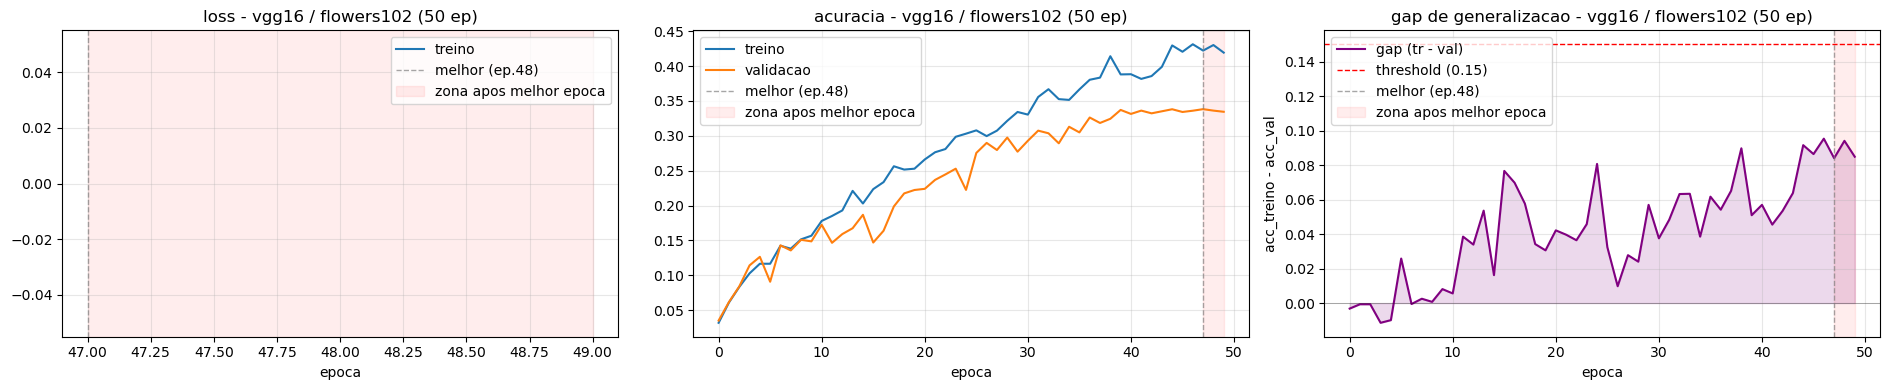


------------------------------------------------------------
 vgg16 | PlainCNN | pets
 params: 0.78M
------------------------------------------------------------


  ep.  1 | mse=0.3838 | acc_tr=0.044 acc_vl=0.052 | gap=-0.008


  ep.  5 | mse=0.3434 | acc_tr=0.101 acc_vl=0.109 | gap=-0.008


  ep. 10 | mse=0.3165 | acc_tr=0.176 acc_vl=0.175 | gap=+0.001


  ep. 15 | mse=0.2953 | acc_tr=0.240 acc_vl=0.219 | gap=+0.021


...

  ep. 30 | mse=0.2507 | acc_tr=0.374 acc_vl=0.330 | gap=+0.043


  ep. 32 | mse=0.2450 | acc_tr=0.385 acc_vl=0.300 | gap=+0.084  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 35 | mse=0.2407 | acc_tr=0.410 acc_vl=0.344 | gap=+0.067


  ep. 40 | mse=0.2334 | acc_tr=0.438 acc_vl=0.364 | gap=+0.074


  early stopping na epoca 42 (sem melhora por 5 epocas). melhor: epoca 37
  melhor acc validacao: 0.3764 (epoca 37)
[timer] final vgg16/pets                              -> 7 min 13.6 s
  melhor acc val : 0.3764
  acc_test (F3)  : 0.3773
  acc_top5       : 0.7584
  checkpoint     : checkpoints/best_student_vgg16_pets.pth


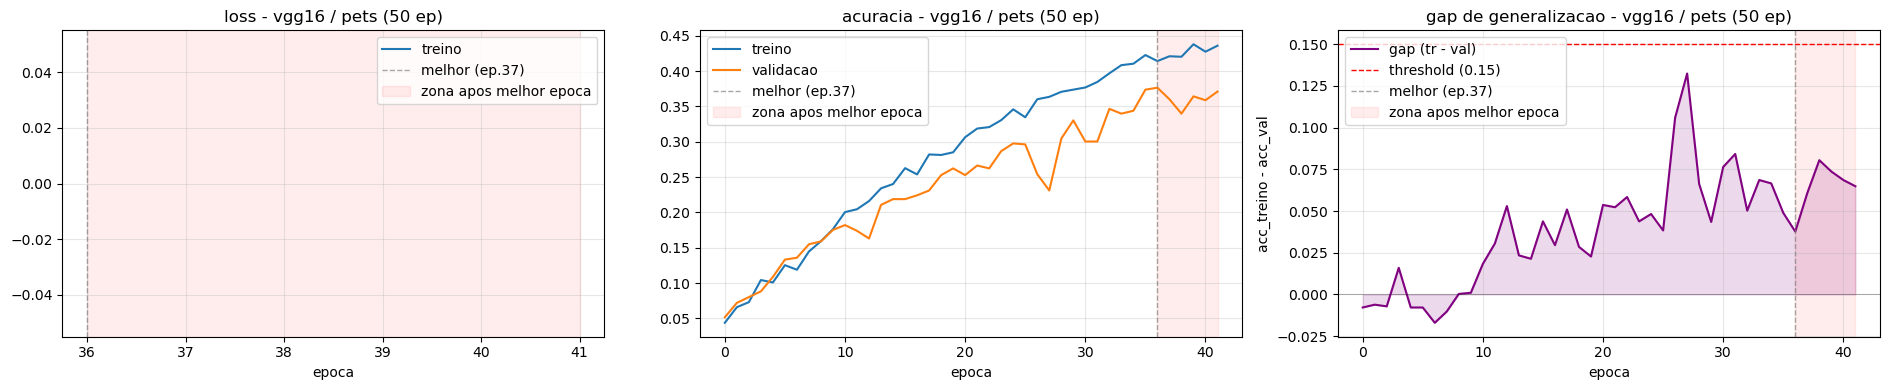


------------------------------------------------------------
 convnext_small | PlainCNN | flowers102
 params: 0.91M
------------------------------------------------------------


  ep.  1 | mse=0.0106 | acc_tr=0.011 acc_vl=0.010 | gap=+0.001


  ep.  5 | mse=0.0076 | acc_tr=0.068 acc_vl=0.087 | gap=-0.019


  ep.  8 | mse=0.0072 | acc_tr=0.088 acc_vl=0.091 | gap=-0.003  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 10 | mse=0.0071 | acc_tr=0.110 acc_vl=0.084 | gap=+0.026


  early stopping na epoca 11 (sem melhora por 5 epocas). melhor: epoca 6
  melhor acc validacao: 0.0928 (epoca 6)
[timer] final convnext_small/flowers102               -> 1 min 11.0 s
  melhor acc val : 0.0928
  acc_test (F3)  : 0.0659
  acc_top5       : 0.2483
  checkpoint     : checkpoints/best_student_convnext_small_flowers102.pth


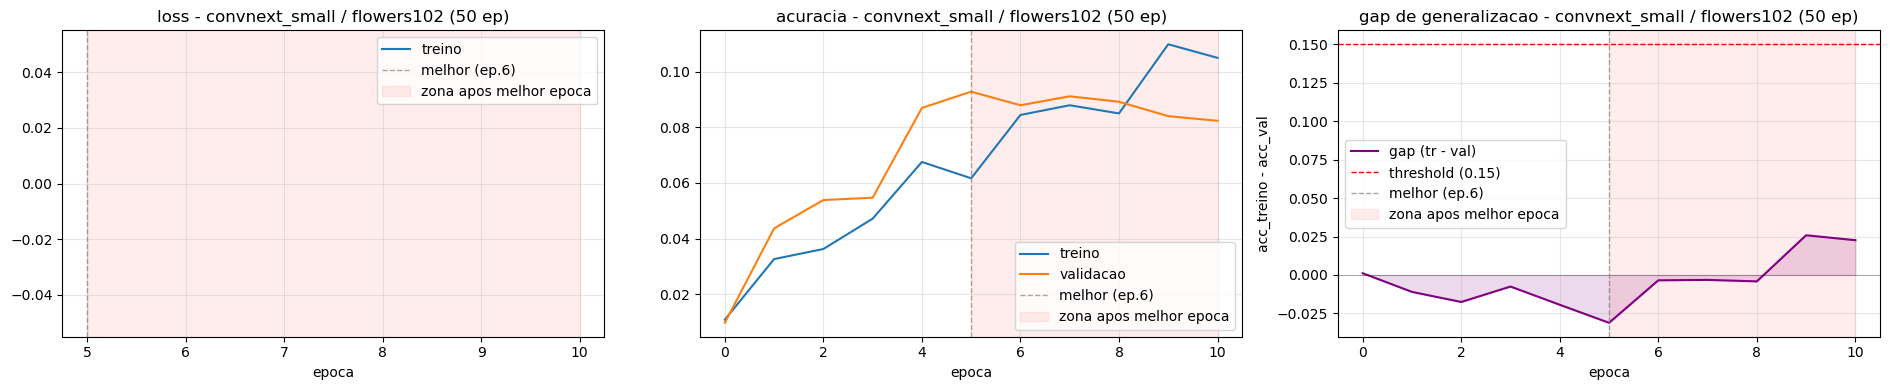


------------------------------------------------------------
 convnext_small | PlainCNN | pets
 params: 0.91M
------------------------------------------------------------


  ep.  1 | mse=0.0136 | acc_tr=0.033 acc_vl=0.039 | gap=-0.006


  ep.  5 | mse=0.0121 | acc_tr=0.058 acc_vl=0.057 | gap=+0.001


  ep. 10 | mse=0.0119 | acc_tr=0.090 acc_vl=0.062 | gap=+0.028


  ep. 15 | mse=0.0115 | acc_tr=0.137 acc_vl=0.118 | gap=+0.018


...

  ep. 25 | mse=0.0106 | acc_tr=0.241 acc_vl=0.198 | gap=+0.042


  ep. 27 | mse=0.0104 | acc_tr=0.274 acc_vl=0.247 | gap=+0.027  [OVERFITTING: val_loss subindo 3x seguidas]


  ep. 30 | mse=0.0103 | acc_tr=0.282 acc_vl=0.243 | gap=+0.039


  ep. 35 | mse=0.0099 | acc_tr=0.322 acc_vl=0.281 | gap=+0.041


  early stopping na epoca 38 (sem melhora por 5 epocas). melhor: epoca 33
  melhor acc validacao: 0.2962 (epoca 33)
[timer] final convnext_small/pets                     -> 6 min 44.6 s
  melhor acc val : 0.2962
  acc_test (F3)  : 0.2454
  acc_top5       : 0.6019
  checkpoint     : checkpoints/best_student_convnext_small_pets.pth


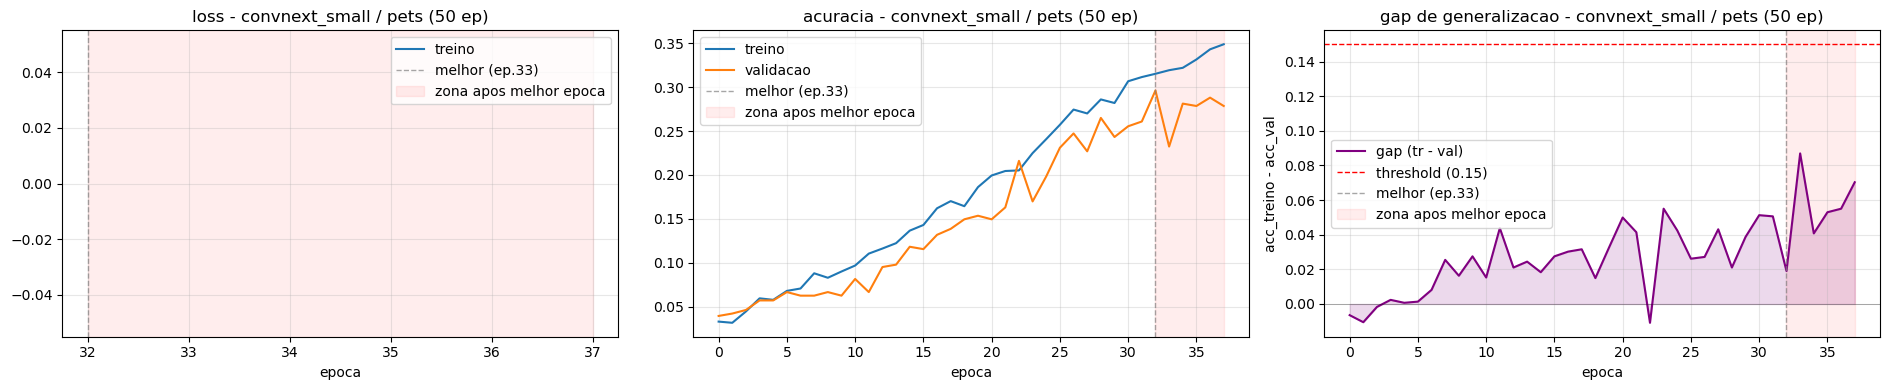

In [14]:
# ── Treino definitivo: best encoder por teacher, 50 ep, 2 datasets ───────────
resultados_final = {}

for nome_teacher in TEACHERS:
    resultados_final[nome_teacher] = {}
    EncoderCls = ENCODER_CLASSES[best_encoder_por_teacher[nome_teacher]]

    for dataset_nome in DATASETS_NOMES:
        teacher = resultados_fase1[nome_teacher][dataset_nome]['teacher_obj'].to(device)

        enc     = EncoderCls(STUDENT_CHANNELS)
        pred    = PreditorPostGAP(enc.out_dim, teacher.feat_dim)
        student = StudentModel(enc, pred).to(device)
        params_s = sum(p.numel() for p in student.parameters()) / 1e6

        print(f'\n{"-"*60}')
        print(f' {nome_teacher} | {best_encoder_por_teacher[nome_teacher]} | {dataset_nome}')
        print(f' params: {params_s:.2f}M')
        print(f'{"-"*60}')

        perda_fn = PerdaKD(alpha=MELHOR_ALPHA)
        with Timer(f'final {nome_teacher}/{dataset_nome}'):
            hist, melhor_acc_val = trainer.treinar_fase2(
                student      = student,
                teacher      = teacher,
                loader_train = DATASETS[dataset_nome]['train'],
                loader_val   = DATASETS[dataset_nome]['val'],
                perda_fn     = perda_fn,
                n_epochs     = EPOCHS_FINAL,
                lr           = LR,
                modo_target  = MELHOR_TARGET,
                descricao    = f'final_{nome_teacher}_{dataset_nome}',
            )

        acc_test, acc_top5 = evaluator.avaliar_fase3(
            student, teacher, DATASETS[dataset_nome]['test'], MELHOR_TARGET)

        print(f'  melhor acc val : {melhor_acc_val:.4f}')
        print(f'  acc_test (F3)  : {acc_test:.4f}')
        if acc_top5:
            print(f'  acc_top5       : {acc_top5:.4f}')

        ckpt = f'checkpoints/best_student_{nome_teacher}_{dataset_nome}.pth'
        torch.save(student.state_dict(), ckpt)
        print(f'  checkpoint     : {ckpt}')

        resultados_final[nome_teacher][dataset_nome] = {
            'student_obj':    student,
            'historico':      hist,
            'melhor_acc_val': melhor_acc_val,
            'acc_test':       acc_test,
            'acc_top5':       acc_top5,
            'params_M':       params_s,
            'encoder':        best_encoder_por_teacher[nome_teacher],
        }

        plotar_curvas(hist, titulo=f'{nome_teacher} / {dataset_nome} (50 ep)')
        student.cpu(); teacher.cpu()


In [15]:
# ── [CHECKPOINT] Salvar resultados do treino definitivo ──────────────────────
# Os best_student_*.pth ja foram salvos durante o treino acima.
# Aqui salvamos o resumo de acc + historicos de convergencia.
salvar_final(resultados_final)
print('Secao 5 concluida e persistida. Proximas secoes podem ser retomadas do disco.')


[checkpoint] final_summary.json e historicos salvos.
Secao 5 concluida e persistida. Proximas secoes podem ser retomadas do disco.


---
## Secao 6 — Q5: MSE+CE vs RKD

Compara os dois esquemas de perda com o melhor student do resnet50:

| Metodo | Formula | O que alinha |
|--------|---------|-------------|
| **MSE+CE** (baseline) | α·L_MSE + (1-α)·L_CE | valores absolutos das features |
| **RKD+CE** | L_RKD + 0.3·L_CE | distancias par-a-par (invariante a escala) |

**Hipotese**: RKD pode superar MSE em *capacity mismatch* (student muito menor que teacher).

Referencia: Park et al., CVPR 2019.


In [16]:
# ── [RESTORE] Secao 6 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()


[ok] resultados_fase1 ja em memoria.


  treinando: MSE_baseline
    melhor acc: 0.3175
  treinando: RKD
    melhor acc: 0.0186
[timer] Q5 — MSE vs RKD                               -> 6 min 3.7 s

 Q5 — MSE+CE baseline vs RKD
  MSE_baseline          melhor_acc_val = 0.3175
  RKD                   melhor_acc_val = 0.0186


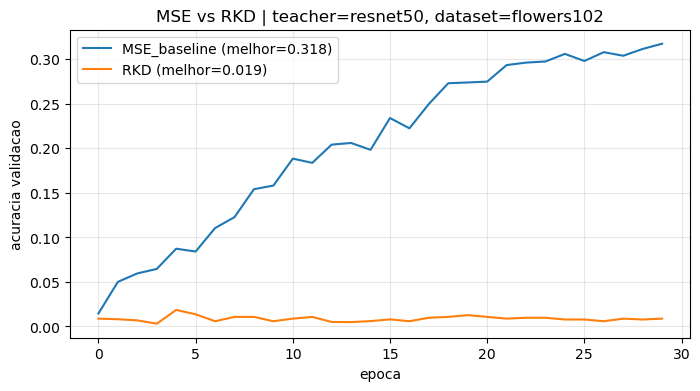

TeacherWrapper(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv

In [17]:
# ── Q5: MSE baseline vs RKD (resnet50, flowers102, best encoder, 30 ep) ───────
teacher_q5 = resultados_fase1['resnet50']['flowers102']['teacher_obj'].to(device)

with Timer('Q5 — MSE vs RKD'):
    resultados_q5 = trainer.comparar_mse_vs_rkd(
        teacher          = teacher_q5,
        datasets         = DATASETS,
        teacher_nome     = 'resnet50',
        dataset_nome     = 'flowers102',
        n_epochs         = 30,
        lr               = LR,
        student_channels = STUDENT_CHANNELS,
    )

print('\n' + '='*55)
print(' Q5 — MSE+CE baseline vs RKD')
print('='*55)
for nome, res in resultados_q5.items():
    print(f'  {nome:20s}  melhor_acc_val = {res["melhor_acc"]:.4f}')

plotar_comparacao_mse_rkd(resultados_q5, 'resnet50', 'flowers102')
teacher_q5.cpu()


In [18]:
# ── [CHECKPOINT] Salvar resultados Q5 ────────────────────────────────────────
with open(f'{CKPT_DIR}/results_q5.pkl', 'wb') as f:
    pickle.dump(resultados_q5, f)
print('[checkpoint] results_q5.pkl salvo.')


[checkpoint] results_q5.pkl salvo.


---
## Secao 7 — GFLOPs e Eficiencia Computacional

O enunciado exige que o student **salve GFLOPs e parametros consideravelmente**
comparado ao teacher.


In [6]:
# ── [RESTORE] Secao 7 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()

try:
    _ = resultados_final
    print('[ok] resultados_final ja em memoria.')
except NameError:
    resultados_final = restaurar_final()

try:
    _ = best_encoder_por_teacher
    print('[ok] best_encoder_por_teacher ja em memoria.')
except NameError:
    with open(f'{CKPT_DIR}/best_encoder.json') as f:
        best_encoder_por_teacher = json.load(f)
    print('[checkpoint] best_encoder_por_teacher carregado do disco.')


NameError: name 'restaurar_fase1' is not defined

In [20]:
# ── tabela de eficiencia: GFLOPs e parametros ─────────────────────────────────
linhas_eff = []

# teachers
for nome_teacher in TEACHERS:
    t = resultados_fase1[nome_teacher]['flowers102']['teacher_obj']
    gf, pr = gflops_params(t)
    linhas_eff.append({
        'modelo': f'{nome_teacher} (teacher)', 'dataset': '—',
        'gflops': gf, 'params_M': pr, 'tipo': 'teacher',
    })

# best students (flowers102, que e onde Q3 foi medido)
for nome_teacher in TEACHERS:
    res = resultados_final[nome_teacher]['flowers102']
    s   = res['student_obj']
    gf, pr = gflops_params(s)
    linhas_eff.append({
        'modelo': f'{res["encoder"]} (student/{nome_teacher})', 'dataset': 'flowers102',
        'gflops': gf, 'params_M': pr, 'tipo': 'student',
    })

df_eff = pd.DataFrame(linhas_eff)

print('Eficiencia Computacional')
print()
print(f'{"modelo":42s} {"gflops":>8s} {"params_M":>10s}')
print('─' * 65)

teacher_params = {}
for _, row in df_eff.iterrows():
    gf_str = f"{row['gflops']:.3f}" if row['gflops'] else 'n/d'
    pr_str = f"{row['params_M']:.2f}M"
    print(f"  {row['modelo']:40s} {gf_str:>8s} {pr_str:>10s}")
    if row['tipo'] == 'teacher':
        t_nome = row['modelo'].split(' ')[0]
        teacher_params[t_nome] = row['params_M']

# reducao relativa
print()
print('Reducao de parametros (student / teacher):')
for nome_teacher in TEACHERS:
    res = resultados_final[nome_teacher]['flowers102']
    reducao = res['params_M'] / teacher_params.get(nome_teacher, 1) * 100
    print(f'  {nome_teacher:20s}  {res["encoder"]:12s}  {res["params_M"]:.2f}M  ({reducao:.1f}%)')


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::max_pool2d encountered 5 time(s)
Unsupported operator aten::gelu encountered 36 time(s)
Unsupported operator aten::mul encountered 36 time(s)
Unsupported operator aten::add_ encountered 36 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
encoder.1.0.stochastic_depth, encoder.1.1.stochastic_depth, encoder.1.2.stochastic_depth, encoder.3.0.stochastic_depth, encoder.3.1.stochastic_depth, encoder.3.2.stochastic_depth, encoder.5.0.stochastic_depth, encoder.5.1.stochastic_depth, encoder.5.10.stochastic_depth, encoder.5.11.stochastic_depth, encoder.5.12.stochastic_depth, encode

Eficiencia Computacional

modelo                                       gflops   params_M
─────────────────────────────────────────────────────────────────
  resnet50 (teacher)                          4.110     23.72M
  vgg16 (teacher)                            15.347     14.77M
  convnext_small (teacher)                    8.705     49.53M
  Depthwise (student/resnet50)                0.035      1.23M
  PlainCNN (student/vgg16)                    0.186      0.78M
  PlainCNN (student/convnext_small)           0.186      0.91M

Reducao de parametros (student / teacher):
  resnet50              Depthwise     1.23M  (5.2%)
  vgg16                 PlainCNN      0.78M  (5.3%)
  convnext_small        PlainCNN      0.91M  (1.8%)


---
## Secao 8 — Relatorio Final Consolidado

Tabela unica com os resultados de todas as questoes.


In [12]:
# ── [RESTORE] Secao 8 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()

try:
    _ = resultados_final
    print('[ok] resultados_final ja em memoria.')
except NameError:
    resultados_final = restaurar_final()

try:
    _ = best_encoder_por_teacher
    print('[ok] best_encoder_por_teacher ja em memoria.')
except NameError:
    with open(f'{CKPT_DIR}/best_encoder.json') as f:
        best_encoder_por_teacher = json.load(f)
    print('[checkpoint] best_encoder_por_teacher carregado do disco.')

try:
    _ = df_q3
    print('[ok] df_q3 ja em memoria.')
except NameError:
    df_q3 = pd.read_csv(f'{CKPT_DIR}/results_q3.csv')
    print('[checkpoint] df_q3 carregado do disco.')

try:
    _ = resultados_q5
    print('[ok] resultados_q5 ja em memoria.')
except NameError:
    with open(f'{CKPT_DIR}/results_q5.pkl', 'rb') as f:
        resultados_q5 = pickle.load(f)
    print('[checkpoint] resultados_q5 carregado do disco.')


/tmp/ipykernel_51580/1097877181.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(ckpt_path, map_location='cpu'))


[checkpoint] resultados_fase1 restaurado do disco.


/tmp/ipykernel_51580/1097877181.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(ckpt, map_location='cpu'))


[checkpoint] resultados_final restaurado do disco.
[checkpoint] best_encoder_por_teacher carregado do disco.
[checkpoint] df_q3 carregado do disco.
[checkpoint] resultados_q5 carregado do disco.


In [13]:
# ── tabela consolidada final ──────────────────────────────────────────────────
linhas_rel = []

# Q1 + treino definitivo: best student por teacher × dataset
for nome_teacher in TEACHERS:
    for dataset_nome in DATASETS_NOMES:
        res = resultados_final[nome_teacher][dataset_nome]
        t_params = sum(
            p.numel() for p in resultados_fase1[nome_teacher][dataset_nome]['teacher_obj'].parameters()
        ) / 1e6
        linhas_rel.append({
            'questao':   'Q1/Q3 — definitivo',
            'teacher':   nome_teacher,
            'encoder':   res['encoder'],
            'dataset':   dataset_nome,
            'alpha':     MELHOR_ALPHA,
            'perda':     'MSE+CE',
            'acc_top1':  res['acc_test'],
            'acc_top5':  res['acc_top5'] if res['acc_top5'] else '—',
            'params_M':  res['params_M'],
            'reducao_%': round(res['params_M'] / t_params * 100, 1),
        })

# Q5
for nome_perda, res in resultados_q5.items():
    t_params = sum(
        p.numel() for p in resultados_fase1['resnet50']['flowers102']['teacher_obj'].parameters()
    ) / 1e6
    s_params = resultados_final['resnet50']['flowers102']['params_M']
    linhas_rel.append({
        'questao':   'Q5',
        'teacher':   'resnet50',
        'encoder':   best_encoder_por_teacher['resnet50'],
        'dataset':   'flowers102',
        'alpha':     '—',
        'perda':     nome_perda,
        'acc_top1':  res['melhor_acc'],
        'acc_top5':  '—',           # comparar_mse_vs_rkd nao retorna top5
        'params_M':  s_params,
        'reducao_%': round(s_params / t_params * 100, 1),
    })

df_rel = pd.DataFrame(linhas_rel)

print('=' * 85)
print(' RELATORIO FINAL — Knowledge Distillation (MO434)')
print('=' * 85)
print(df_rel[['questao','teacher','encoder','dataset','perda','alpha',
              'acc_top1','acc_top5','params_M','reducao_%']].to_string(index=False))

# ── Q1 pivot top-1 e top-5 ────────────────────────────────────────────────────
print('\n--- Q1: acc_top1 por teacher × dataset ---')
piv1 = df_rel[df_rel['questao'] == 'Q1/Q3 — definitivo'].pivot_table(
    index='teacher', columns='dataset', values='acc_top1')
print(piv1.to_string())

# top-5 (flowers102: 102 classes — top-5 e muito informativo)
df_t5 = df_rel[
    (df_rel['questao'] == 'Q1/Q3 — definitivo') &
    (df_rel['acc_top5'] != '—')
].copy()
df_t5['acc_top5'] = pd.to_numeric(df_t5['acc_top5'], errors='coerce')
if not df_t5.empty and df_t5['acc_top5'].notna().any():
    print('\n--- Q1: acc_top5 por teacher × dataset ---')
    piv5 = df_t5.pivot_table(index='teacher', columns='dataset', values='acc_top5')
    print(piv5.to_string())

# ── Q3 resumo ─────────────────────────────────────────────────────────────────
print('\n--- Q3: melhor encoder por teacher (flowers102, 50 ep) ---')
print(f'  {"teacher":20s} {"encoder":12s} {"acc_top1":>9s} {"acc_top5":>9s} {"params_M":>9s} {"reducao":>8s}')
print('  ' + '-'*72)
for t in TEACHERS:
    enc = best_encoder_por_teacher[t]
    res = resultados_final[t]['flowers102']
    top5_str = f"{res['acc_top5']:.4f}" if res['acc_top5'] else '  —   '
    reducao  = round(res['params_M'] / sum(
        p.numel() for p in resultados_fase1[t]['flowers102']['teacher_obj'].parameters()
    ) * 1e-6 * 100, 1)
    print(f"  {t:20s} {enc:12s} {res['acc_test']:>9.4f} {top5_str:>9s} {res['params_M']:>7.2f}M {reducao:>7.1f}%")

# ── Q5 ────────────────────────────────────────────────────────────────────────
print('\n--- Q5: MSE+CE vs RKD ---')
q5_tab = df_rel[df_rel['questao'] == 'Q5'][['perda', 'acc_top1']]
print(q5_tab.to_string(index=False))


 RELATORIO FINAL — Knowledge Distillation (MO434)
           questao        teacher   encoder    dataset        perda alpha  acc_top1  acc_top5  params_M  reducao_%
Q1/Q3 — definitivo       resnet50 Depthwise flowers102       MSE+CE   0.5  0.306736  0.591095  1.229504        5.2
Q1/Q3 — definitivo       resnet50 Depthwise       pets       MSE+CE   0.5  0.239946  0.595005  1.229504        5.2
Q1/Q3 — definitivo          vgg16  PlainCNN flowers102       MSE+CE   0.5  0.276587  0.556444  0.783136        5.3
Q1/Q3 — definitivo          vgg16  PlainCNN       pets       MSE+CE   0.5  0.377342  0.758385  0.783136        5.3
Q1/Q3 — definitivo convnext_small  PlainCNN flowers102       MSE+CE   0.5  0.065900  0.248348  0.914464        1.8
Q1/Q3 — definitivo convnext_small  PlainCNN       pets       MSE+CE   0.5  0.245380  0.601928  0.914464        1.8
                Q5       resnet50 Depthwise flowers102 MSE_baseline     —  0.317522         —  1.229504        5.2
                Q5       resne

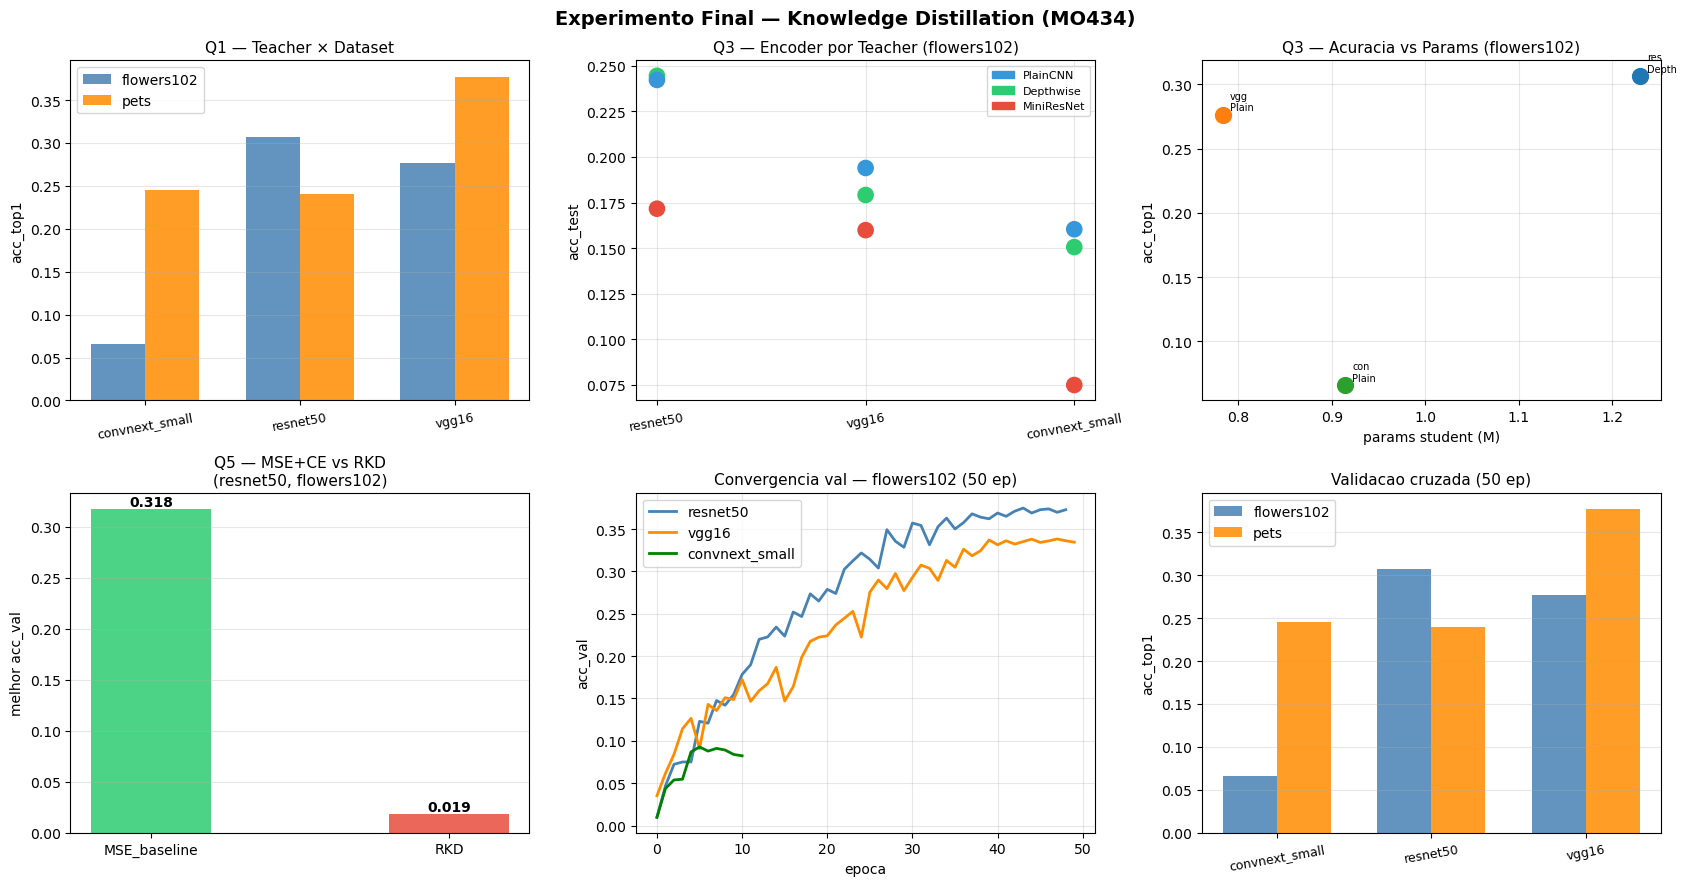


 Resumo de Tempos da Sessao
  carregamento dos datasets                         0.30 s
----------------------------------------------------------
  TOTAL                                         0.30 s


In [16]:
# ── graficos finais ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# --- Q1: acc por teacher × dataset ---
ax = axes[0, 0]
piv_plot = df_rel[df_rel['questao'] == 'Q1/Q3 — definitivo'].pivot_table(
    index='teacher', columns='dataset', values='acc_top1')
x = range(len(piv_plot))
w = 0.35
ax.bar([xi - w/2 for xi in x], piv_plot.get('flowers102', [0]*3),
       width=w, label='flowers102', color='steelblue', alpha=0.85)
ax.bar([xi + w/2 for xi in x], piv_plot.get('pets', [0]*3),
       width=w, label='pets', color='darkorange', alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(piv_plot.index, rotation=10, fontsize=9)
ax.set_title('Q1 — Teacher × Dataset', fontsize=11)
ax.set_ylabel('acc_top1'); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# --- Q3: encoder por teacher (flowers102) ---
ax = axes[0, 1]
sub_q3 = df_q3.copy()
cores_enc = {'PlainCNN': '#3498db', 'Depthwise': '#2ecc71', 'MiniResNet': '#e74c3c'}
for i, t in enumerate(TEACHERS):
    d = sub_q3[sub_q3['teacher'] == t].sort_values('encoder')
    ax.scatter([i]*len(d), d['acc_test'],
               c=[cores_enc.get(enc, 'gray') for enc in d['encoder']],
               s=120, zorder=5)
ax.set_xticks(range(len(TEACHERS))); ax.set_xticklabels(TEACHERS, rotation=10, fontsize=9)
ax.set_title('Q3 — Encoder por Teacher (flowers102)', fontsize=11)
ax.set_ylabel('acc_test'); ax.grid(True, alpha=0.3)
# legenda manual
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=e) for e, c in cores_enc.items()], fontsize=8)

# --- Q3: acuracia vs params ---
ax = axes[0, 2]
sub_def = df_rel[df_rel['questao'] == 'Q1/Q3 — definitivo']
for _, row in sub_def[sub_def['dataset'] == 'flowers102'].iterrows():
    ax.scatter(row['params_M'], row['acc_top1'], s=130, zorder=5)
    ax.annotate(f"{row['teacher'][:3]}\n{row['encoder'][:5]}",
                (row['params_M'], row['acc_top1']),
                textcoords='offset points', xytext=(5,3), fontsize=7)
ax.set_title('Q3 — Acuracia vs Params (flowers102)', fontsize=11)
ax.set_xlabel('params student (M)'); ax.set_ylabel('acc_top1'); ax.grid(True, alpha=0.3)

# --- Q5: MSE vs RKD ---
ax = axes[1, 0]
q5_plot = df_rel[df_rel['questao'] == 'Q5']
cores_q5 = {'MSE_baseline': '#2ecc71', 'RKD': '#e74c3c'}
bars = ax.bar(q5_plot['perda'], q5_plot['acc_top1'],
              color=[cores_q5.get(p, 'steelblue') for p in q5_plot['perda']],
              alpha=0.85, width=0.4)
for bar, (_, row) in zip(bars, q5_plot.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{row['acc_top1']:.3f}", ha='center', fontsize=10, fontweight='bold')
ax.set_title('Q5 — MSE+CE vs RKD\n(resnet50, flowers102)', fontsize=11)
ax.set_ylabel('melhor acc_val'); ax.grid(True, alpha=0.3, axis='y')

# --- curvas de convergencia: best students (flowers102) ---
ax = axes[1, 1]
cores_t = {'resnet50': 'steelblue', 'vgg16': 'darkorange', 'convnext_small': 'green'}
for t in TEACHERS:
    hist = resultados_final[t]['flowers102']['historico']
    ep = range(len(hist['acc_vl']))
    ax.plot(ep, hist['acc_vl'], label=t, color=cores_t[t], linewidth=2)
ax.set_title('Convergencia val — flowers102 (50 ep)', fontsize=11)
ax.set_xlabel('epoca'); ax.set_ylabel('acc_val'); ax.legend(); ax.grid(True, alpha=0.3)

# --- validacao cruzada: flowers102 vs pets por teacher ---
ax = axes[1, 2]
sub_cross = df_rel[df_rel['questao'] == 'Q1/Q3 — definitivo']
piv_cross = sub_cross.pivot_table(index='teacher', columns='dataset', values='acc_top1')
x2 = range(len(piv_cross))
ax.bar([xi - w/2 for xi in x2], piv_cross.get('flowers102', [0]*3),
       width=w, label='flowers102', color='steelblue', alpha=0.85)
ax.bar([xi + w/2 for xi in x2], piv_cross.get('pets', [0]*3),
       width=w, label='pets', color='darkorange', alpha=0.85)
ax.set_xticks(list(x2)); ax.set_xticklabels(piv_cross.index, rotation=10, fontsize=9)
ax.set_title('Validacao cruzada (50 ep)', fontsize=11)
ax.set_ylabel('acc_top1'); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Experimento Final — Knowledge Distillation (MO434)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Timer.resumo()

---
## Secao 9 — Analise Qualitativa

O enunciado exige *"quantitative and qualitative results on each dataset, with illustrations"*.

### 9.1 Exemplos de predicao: Teacher vs Student

Cada imagem mostra a predicao do teacher (T) e do student (S) com a classe verdadeira (gt).
A borda indica o resultado combinado:

| Borda | Significado |
|-------|-------------|
| **Verde** | Ambos corretos |
| **Laranja** | Apenas teacher correto (student errou) |
| **Vermelho** | Ambos errados |

### 9.2 t-SNE do espaco de features

Compara a geometria do espaco de representacoes do teacher (features post-GAP reais)
com a do student (predicoes do preditor). Clusters similares indicam boa transferencia:
o student aprendeu a organizar o espaco de features de forma parecida com o teacher.


In [17]:
# ── [RESTORE] Secao 9 — restaurar dependencias se necessario ─────────────────
# Execute esta celula se voce esta retomando o notebook a partir desta secao.
# Pre-requisito: Secoes 0 (imports/config) e 1 (datasets) ja executadas.
try:
    _ = resultados_fase1
    print('[ok] resultados_fase1 ja em memoria.')
except NameError:
    resultados_fase1 = restaurar_fase1()

try:
    _ = resultados_final
    print('[ok] resultados_final ja em memoria.')
except NameError:
    resultados_final = restaurar_final()

try:
    _ = best_encoder_por_teacher
    print('[ok] best_encoder_por_teacher ja em memoria.')
except NameError:
    with open(f'{CKPT_DIR}/best_encoder.json') as f:
        best_encoder_por_teacher = json.load(f)
    print('[checkpoint] best_encoder_por_teacher carregado do disco.')


[ok] resultados_fase1 ja em memoria.
[ok] resultados_final ja em memoria.
[ok] best_encoder_por_teacher ja em memoria.


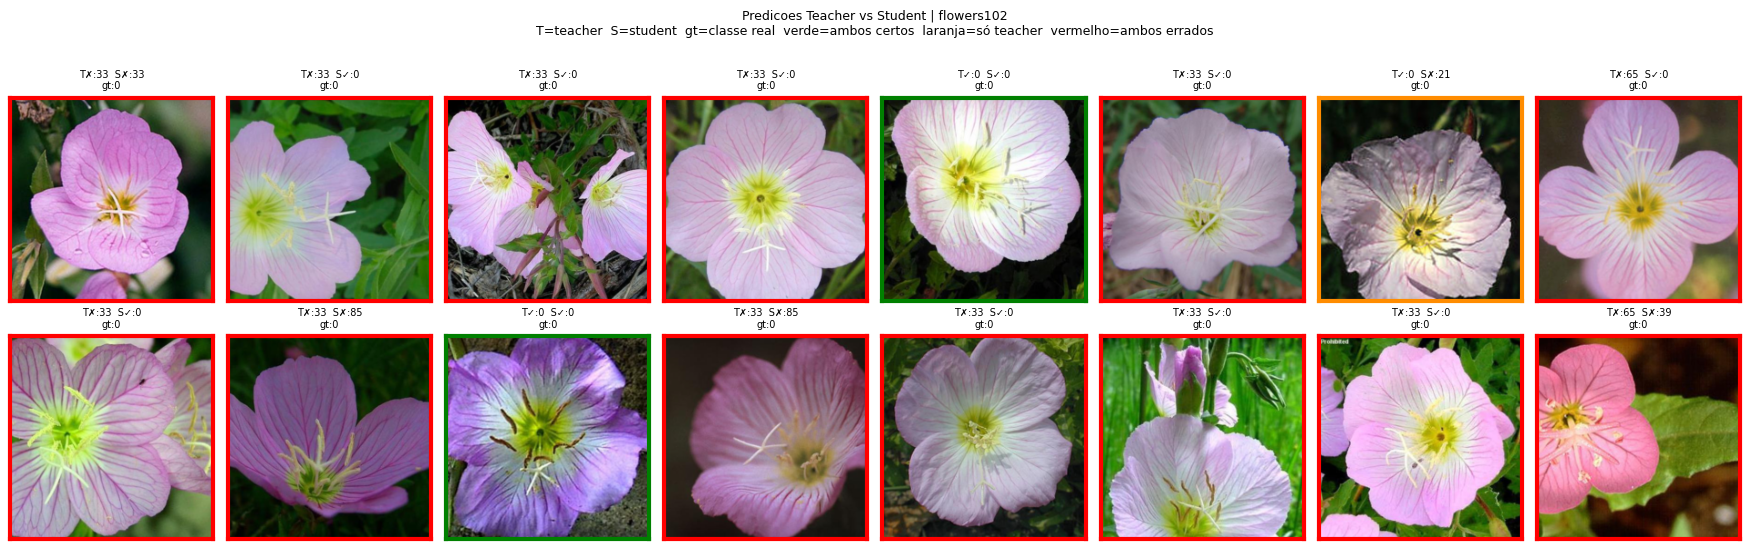

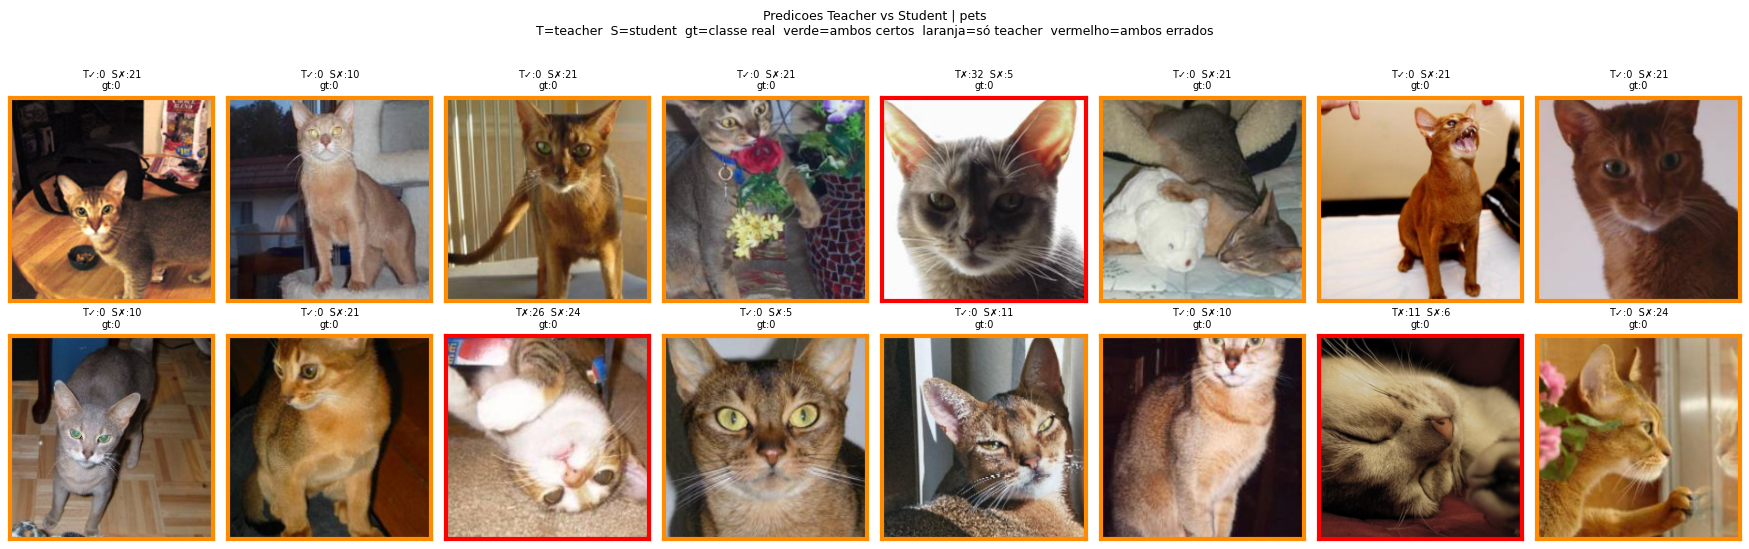

In [19]:
# ── 9.1 Exemplos de predicao: Teacher vs Student ─────────────────────────────
@torch.no_grad()
def visualizar_exemplos(student, teacher, loader_test, n_imgs=16,
                        dataset_nome='flowers102'):
    """
    Mostra n_imgs imagens do conjunto de teste com as predicoes do teacher e do student.

    Borda verde  = ambos corretos
    Borda laranja = so teacher correto (student errou — gap de transferencia)
    Borda vermelha = ambos errados
    """
    student.eval(); teacher.eval()

    # coleta um batch do teste
    imgs, labels = next(iter(loader_test))
    imgs, labels = imgs[:n_imgs].to(device), labels[:n_imgs].to(device)

    # predicoes do teacher (features reais + classificador)
    feat_t   = teacher.get_post_gap(imgs)
    logits_t = teacher.classifier(feat_t)
    preds_t  = logits_t.argmax(1)

    # predicoes do student (preditor -> mesmo classificador do teacher)
    pred_s   = student(imgs)
    logits_s = teacher.classifier(pred_s)
    preds_s  = logits_s.argmax(1)

    # desfaz normalizacao imagenet para exibir
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)

    n_cols = 8
    n_rows = (n_imgs + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 2.2, n_rows * 2.8))
    axes = axes.flatten()

    for i in range(n_imgs):
        ax  = axes[i]
        img = (imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)

        true  = labels[i].item()
        t_ok  = preds_t[i].item() == true
        s_ok  = preds_s[i].item() == true

        # borda indica resultado
        cor = 'green' if (t_ok and s_ok) else ('darkorange' if t_ok else 'red')
        for sp in ax.spines.values():
            sp.set_edgecolor(cor)
            sp.set_linewidth(3)

        # titulo: predicao teacher | predicao student | verdadeiro
        icone_t = '✓' if t_ok else '✗'
        icone_s = '✓' if s_ok else '✗'
        ax.set_title(f'T{icone_t}:{preds_t[i].item()}  S{icone_s}:{preds_s[i].item()}'
                     f'\ngt:{true}', fontsize=7)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    for i in range(n_imgs, len(axes)):
        axes[i].axis('off')

    plt.suptitle(
        f'Predicoes Teacher vs Student | {dataset_nome}\n'
        f'T=teacher  S=student  gt=classe real  '
        f'verde=ambos certos  laranja=só teacher  vermelho=ambos errados',
        fontsize=9, y=1.01)
    plt.tight_layout()
    plt.show()


# ── executa para o melhor teacher (resnet50) nos dois datasets ────────────────
for ds in DATASETS_NOMES:
    t_viz = resultados_fase1['resnet50'][ds]['teacher_obj'].to(device)
    s_viz = resultados_final['resnet50'][ds]['student_obj'].to(device)
    visualizar_exemplos(s_viz, t_viz, DATASETS[ds]['test'],
                        n_imgs=16, dataset_nome=ds)
    t_viz.cpu(); s_viz.cpu()


In [20]:
# ── 9.2 t-SNE: espaco de features do Teacher vs Student ──────────────────────
@torch.no_grad()
def plotar_tsne(student, teacher, loader_test, n_amostras=500,
                dataset_nome='flowers102'):
    """
    Projeta em 2D (via PCA + t-SNE) as features do teacher e as predicoes
    do student, colorindo cada ponto pela classe verdadeira.

    Clusters similares entre os dois mapas indicam que o student aprendeu
    a geometria relacional do espaco do teacher (objetivo do KD).
    """
    try:
        from sklearn.manifold import TSNE
        from sklearn.decomposition import PCA
    except ImportError:
        print('sklearn nao instalado. Execute: pip install scikit-learn')
        return

    student.eval(); teacher.eval()

    feats_t, feats_s, lbls = [], [], []
    total = 0

    for imgs, labels in loader_test:
        if total >= n_amostras:
            break
        imgs = imgs.to(device)
        feats_t.append(teacher.get_post_gap(imgs).cpu())  # features reais do teacher
        feats_s.append(student(imgs).cpu())                # predicoes do student
        lbls.append(labels)
        total += len(imgs)

    ft = torch.cat(feats_t)[:n_amostras].numpy()
    fs = torch.cat(feats_s)[:n_amostras].numpy()
    lb = torch.cat(lbls)[:n_amostras].numpy()

    # PCA para 50 dims antes do t-SNE (acelera muito sem perder estrutura)
    n_comp = min(50, ft.shape[1], fs.shape[1], n_amostras - 1)
    pca    = PCA(n_components=n_comp, random_state=42)
    ft_r   = pca.fit_transform(ft)
    fs_r   = pca.fit_transform(fs)

    print(f'Executando t-SNE ({n_amostras} amostras)...')
    tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
                  n_iter=1000, init='pca')
    ft_2d  = tsne.fit_transform(ft_r)
    fs_2d  = tsne.fit_transform(fs_r)

    # usa no maximo 20 cores distintas (tab20) para classes
    cores_cls = lb % 20

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    kw = dict(s=10, alpha=0.65, cmap='tab20', vmin=0, vmax=19)

    axes[0].scatter(ft_2d[:, 0], ft_2d[:, 1], c=cores_cls, **kw)
    axes[0].set_title(f't-SNE — Features TEACHER\n(resnet50, {dataset_nome})',
                      fontsize=11)
    axes[0].axis('off')

    axes[1].scatter(fs_2d[:, 0], fs_2d[:, 1], c=cores_cls, **kw)
    axes[1].set_title(f't-SNE — Predicoes STUDENT\n({best_encoder_por_teacher["resnet50"]}'
                      f', {dataset_nome})', fontsize=11)
    axes[1].axis('off')

    plt.suptitle(
        'Espaco de features: Teacher vs Student\n'
        'Clusters similares indicam boa transferencia de conhecimento (KD)',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── executa t-SNE para resnet50 nos dois datasets ─────────────────────────────
for ds in DATASETS_NOMES:
    t_tsne = resultados_fase1['resnet50'][ds]['teacher_obj'].to(device)
    s_tsne = resultados_final['resnet50'][ds]['student_obj'].to(device)
    plotar_tsne(s_tsne, t_tsne, DATASETS[ds]['test'],
                n_amostras=500, dataset_nome=ds)
    t_tsne.cpu(); s_tsne.cpu()


sklearn nao instalado. Execute: pip install scikit-learn
sklearn nao instalado. Execute: pip install scikit-learn
